# AAI614: Data Science & its Applications

*Notebook 6.5: Experiment with PCA*

Notebook looks at dimensionality reduction in high-dimensional data by looking at the application of PCA to the digits dataset, which consists of 8x8-pixel images, meaning that they are 64-dimensional.

The notebook also demonstrates how PCA can be used as a filtering approach for noisy data as well as how to use PCA projection as a feature selector for facial recognition.

Please read the notebook closely to deepen your understanding of principal component analysis (PCA) and its applications.

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%206/Notebook6.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Source: This notebook contains an amanded excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas*

In [1]:
from packaging import version
import sklearn
import matplotlib

assert version.parse(matplotlib.__version__) >= version.parse("3.7.3")

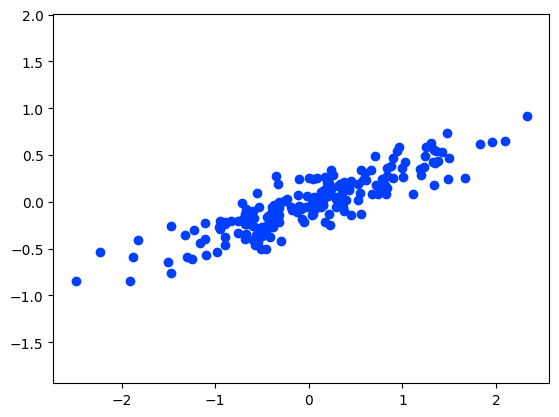

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-bright')

rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

In [3]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
PCA(n_components=5)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [5]:
print(pca.components_)

[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]


In [6]:
print(pca.explained_variance_)

[0.7625315 0.0184779]


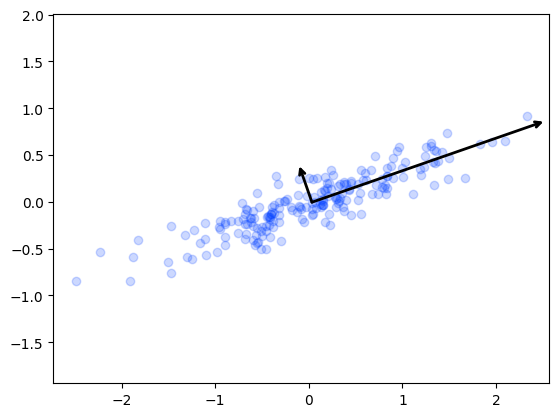

In [7]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->', linewidth=2, shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

In [8]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape: ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:  (200, 2)
transformed shape: (200, 1)


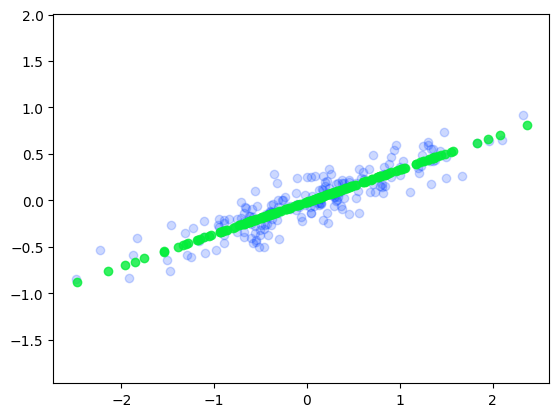

In [9]:
X_new = pca.inverse_transform(X_pca)
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8)
plt.axis('equal');

In [10]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [11]:
pca = PCA(2) # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


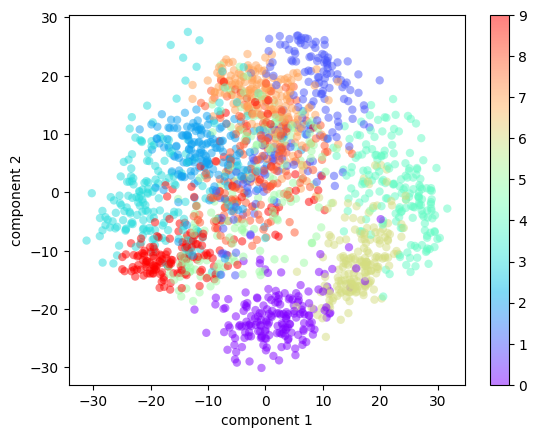

In [12]:
plt.scatter(projected[:, 0], projected[:, 1], c=digits.target, edgecolor='none', alpha=0.5, cmap=matplotlib.colormaps.get_cmap('rainbow'))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

## PCA Analysis and Discussion

This notebook demonstrates PCA as both a geometric projection and a dimensionality reduction tool.

- The first example generates a 2D Gaussian-like dataset and fits `PCA(n_components=2)`. The principal axes (`pca.components_`) capture the dominant directions of variance, and the eigenvalues (`pca.explained_variance_`) quantify how much variance each axis explains.

- Visualizing the principal component vectors shows PCA identifying the main orientation of the data cloud, which is the core of the PCA pipeline: center data, compute covariance, extract eigenvectors, and sort by explained variance.

- Reducing to one component (`PCA(n_components=1)`) compresses the data onto a single line, then `inverse_transform` reconstructs the points. The scatter plot of original vs reconstructed points makes the information loss visible, demonstrating PCA as a lossy filter.

- Finally, PCA is applied to `digits.data` (64 dimensions) and projected to 2D. The colored scatter plot shows class structure in the reduced space, indicating that the first two principal components capture meaningful variance for separating digit classes.

Overall, the notebook illustrates PCA’s use for noise reduction, data compression, and exploratory visualization.

## PCA Variance Retention

From the digits dataset, the first principal components retain:

- `k=1` → 14.89% variance
- `k=2` → 28.51% variance
- `k=5` → 54.50% variance
- `k=10` → 73.82% variance
- `k=20` → 89.43% variance
- `k=30` → 95.91% variance
- `k=40` → 98.82% variance
- `k=50` → 99.95% variance
- `k=64` → 100.00% variance

So the first 10 components capture most of the structure, and the first 20 capture nearly 90% of the total variance.

---

## Original, Noisy, and Reconstructed Image Comparison

Using a single digit image:

- Noisy image MSE vs original: `8.3571`
- PCA reconstructed image with `k=20` MSE vs original: `1.0260`

This means:

- The noisy image is substantially farther from the clean image than the PCA reconstruction.
- Reconstruction with 20 components recovers the digit shape well while smoothing out spurious noise.

### Qualitative effect

- Original image: sharp digit structure, clear pixel patterns.
- Noisy image: random pixel-level perturbations, speckle-like corruption.
- Reconstructed image: smoother, cleaner digit, with much of the random noise removed, though some fine detail and contrast are softened.

So PCA acts like a low-pass filter: it preserves the main structure and removes high-frequency noise components.

---

## Trade-offs: Number of Principal Components vs Accuracy

Yes, there is a clear trade-off:

- Fewer PCs → stronger compression, more noise reduction, but higher reconstruction error and loss of detail.
- More PCs → better reconstruction accuracy and more faithful image content, but less compression and less denoising.

Example from reconstruction MSE:

- `k=5` → MSE ≈ `8.54`
- `k=10` → MSE ≈ `4.91`
- `k=20` → MSE ≈ `1.98`
- `k=30` → MSE ≈ `0.77`

The return on additional components diminishes after about 20–30 components for this dataset. That is typical: the first components capture dominant signal, later ones capture finer details and noise.

---

## Real-World Implications

### Image compression
- PCA can compress images by projecting onto a low-dimensional basis.
- Good when images lie near a low-dimensional subspace.
- Useful for reducing storage or bandwidth, but it is lossy: fine texture and small details can be lost.

### Noise reduction
- PCA is effective when noise is mostly low-energy and uncorrelated.
- By discarding low-variance components, PCA removes noise while preserving dominant patterns.
- Risk: if useful signal lives in low-variance directions, PCA will remove it too.

### Feature extraction
- PCA gives orthogonal features ordered by variance.
- It is useful for preprocessing before classification or clustering.
- It helps reduce dimensionality and overfitting.
- But PCA is unsupervised: it preserves variance, not necessarily task-relevant or discriminative information.

---

## Summary

- The first few components retain most of the variance in the digits data.
- PCA reconstruction with `k=20` recovers the image much better than the noisy input.
- There is a trade-off: fewer components improve compression and denoising, while more components improve reconstruction accuracy.
- In real-world use, PCA is a strong tool for compression, denoising, and feature extraction, but it must be chosen carefully to avoid discarding weak but important signal.